In [6]:
# Cell 1 — Install dependencies
import subprocess
pkgs = ['torch','torchvision','opencv-python','scikit-learn',
        'matplotlib','pandas','numpy','tqdm']
subprocess.run(['pip','install','--quiet'] + pkgs, check=False)
print("✅ Dependencies ready")

✅ Dependencies ready


In [7]:
# Cell 2 — Upload your ZIP and auto-extract
# ─────────────────────────────────────────────────────────────────
# Upload the ZIP file from your PC using the file picker below.
# The code will automatically find and extract both dataset folders.
# ─────────────────────────────────────────────────────────────────
import os, zipfile, glob
from google.colab import files

print("📁 Please select your ZIP file (archive (2) (5).zip or similar)...")
uploaded = files.upload()   # ← opens file picker

zip_name = list(uploaded.keys())[0]
print(f"\n📦 Uploaded: {zip_name}  ({len(uploaded[zip_name])/1e6:.1f} MB)")

# Write the bytes to disk
zip_path = f'/content/{zip_name}'
with open(zip_path, 'wb') as f:
    f.write(uploaded[zip_name])

# Extract
print("📂 Extracting...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/')
print("✅ Extraction done")

# ── Auto-locate both dataset folders ──────────────────────────────
def find_datasets(search_root='/content'):
    """Walk the directory tree and find all folders containing driving_log.csv"""
    found = []
    for dirpath, dirnames, filenames in os.walk(search_root):
        if 'driving_log.csv' in filenames:
            found.append(dirpath)
    return found

dataset_paths = find_datasets()
print(f"\n🗂️  Found {len(dataset_paths)} dataset(s):")
for p in dataset_paths:
    print(f"   {p}")

if not dataset_paths:
    print("\n⚠️  No driving_log.csv found — check your ZIP structure!")
    print("   Expected structure inside the ZIP:")
    print("     self_driving_car_dataset_jungle/")
    print("       IMG/")
    print("       driving_log.csv")
    print("     self_driving_car_dataset_make/")
    print("       IMG/")
    print("       driving_log.csv")

📁 Please select your ZIP file (archive (2) (5).zip or similar)...


Saving archive (2) (5).zip to archive (2) (5) (1).zip

📦 Uploaded: archive (2) (5) (1).zip  (294.4 MB)
📂 Extracting...
✅ Extraction done

🗂️  Found 2 dataset(s):
   /content/self_driving_car_dataset_jungle
   /content/self_driving_car_dataset_make


Let's check the contents of the `/content/` directory to see what files and folders are present. This will help us confirm the actual path to your data.

In [10]:
# Cell 3 — Imports & Config
import os, cv2, time, copy, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ╔══════════════════════════════════════════════════════════════════╗
# ║  CONFIG                                                         ║
# ║  DATA_PATHS is set automatically from Cell 2.                   ║
# ║  If you skipped Cell 2, set DATA_PATHS manually below.          ║
# ╚══════════════════════════════════════════════════════════════════╝
CFG = {
    # ── Populated automatically from Cell 2 ──────────────────────
    # Set manually if you skipped Cell 2, e.g.:
    # 'DATA_PATHS': ['/content/self_driving_car_dataset_jungle',
    #                '/content/self_driving_car_dataset_make'],
    'DATA_PATHS': dataset_paths if 'dataset_paths' in dir() else [],

    # ── Image crop ───────────────────────────────────────────────
    # Your images are 160×320. Sky ≈ top 40%, hood ≈ bottom 15%
    'CROP_TOP'  : 55,
    'CROP_BOT'  : 20,
    'IMG_H'     : 66,
    'IMG_W'     : 200,

    # ── Steering thresholds ──────────────────────────────────────
    'STRAIGHT_LO': -0.08,
    'STRAIGHT_HI':  0.08,
    'LEFT_THRESH' : -0.15,
    'RIGHT_THRESH':  0.15,

    # ── GAN ──────────────────────────────────────────────────────
    'GAN_LATENT'  : 100,
    'GAN_EPOCHS'  : 150,   # use 30 for quick test
    'GAN_LR'      : 2e-4,
    'GAN_IMG_SIZE': 64,
    'GAN_BATCH'   : 32,
    'SYNTH_MULTI' : 2.5,

    # ── Training ─────────────────────────────────────────────────
    'EPOCHS'      : 60,
    'BATCH'       : 32,
    'LR'          : 1e-3,
    'PATIENCE'    : 10,
    'WEIGHT_DECAY': 1e-4,
    'CURVE_DIM'   : 6,
    'SEED'        : 42,
}

torch.manual_seed(CFG['SEED'])
np.random.seed(CFG['SEED'])

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU    : {torch.cuda.get_device_name(0)}")
print(f"   Datasets: {CFG['DATA_PATHS']}")

✅ Device  : cuda
   GPU    : Tesla T4
   Datasets: ['/content/self_driving_car_dataset_jungle', '/content/self_driving_car_dataset_make']


Based on the output above, please identify the *actual directory* that contains `driving_log.csv` and the `IMG` folder. If it's a directory like `archive (2) (5)` (without the `.zip` extension), or some other folder, you'll need to update the `CFG['DATA_PATH']` in the configuration cell above (cell `Aj2_HcfMuSno`) to point to that directory. Then re-run all cells from the configuration cell onwards.

In [11]:
# Cell 4 — Load & Combine Both Datasets
def find_img_folder(data_path):
    """Find the image sub-folder inside a dataset folder.
    Handles: IMG/, images/, img/, or any folder with .jpg files."""
    for candidate in ['IMG', 'images', 'img', 'Images']:
        p = os.path.join(data_path, candidate)
        if os.path.isdir(p):
            return p + '/'
    # Fallback: first sub-folder that contains .jpg files
    try:
        for sub in os.listdir(data_path):
            sp = os.path.join(data_path, sub)
            if os.path.isdir(sp) and glob.glob(sp + '/*.jpg'):
                return sp + '/'
    except Exception:
        pass
    return None


def load_single_dataset(data_path):
    """Load one dataset. Returns DataFrame with columns:
       img_path | steering | throttle | brake | speed | dataset
    """
    data_path = data_path.rstrip('/')
    csv_path  = os.path.join(data_path, 'driving_log.csv')

    if not os.path.exists(csv_path):
        print(f"  ⚠️  Skipping {data_path} — driving_log.csv not found")
        return pd.DataFrame()

    df = pd.read_csv(csv_path, header=None)
    df.columns = ['center','left','right','steering','throttle','brake','speed']
    df['steering'] = df['steering'].clip(-1.0, 1.0)

    img_folder = find_img_folder(data_path)
    if img_folder is None:
        print(f"  ⚠️  Cannot find image folder inside {data_path}")
        return pd.DataFrame()
    print(f"  Image folder: {img_folder}")

    def make_path(raw):
        # The CSV stores full Windows paths like:
        # C:\Users\...\IMG\center_2022_04_10_12_44_30_446.jpg
        # We just need the filename.
        fname = str(raw).replace('\\', '/').replace('\\\\', '/').split('/')[-1].strip()
        return img_folder + fname

    records = []
    for col, offset in [('center', 0.0), ('left', +0.20), ('right', -0.20)]:
        sub = df[[col, 'steering', 'throttle', 'brake', 'speed']].copy()
        sub['steering']  = (sub['steering'] + offset).clip(-1.0, 1.0)
        sub['img_path']  = sub[col].apply(make_path)
        sub = sub.drop(columns=[col])
        sub = sub[sub['img_path'].apply(os.path.exists)].reset_index(drop=True)
        records.append(sub)
        print(f"    {col:6s} cam → {len(sub):,} valid images  (offset={offset:+.2f})")

    return pd.concat(records, ignore_index=True)


# ── Load all datasets ─────────────────────────────────────────────
if not CFG['DATA_PATHS']:
    raise RuntimeError(
        "DATA_PATHS is empty!\n"
        "Either run Cell 2 first, or manually set CFG['DATA_PATHS'] in Cell 3."
    )

all_dfs = []
for dpath in CFG['DATA_PATHS']:
    print(f"\n📂 Loading: {dpath}")
    d = load_single_dataset(dpath)
    if len(d) > 0:
        d['dataset'] = os.path.basename(dpath)
        all_dfs.append(d)
        print(f"   → {len(d):,} total samples")

if not all_dfs:
    raise RuntimeError(
        "No valid data loaded.\n"
        "Check that driving_log.csv and the IMG/ folder are present."
    )

full_df = (pd.concat(all_dfs, ignore_index=True)
             .sample(frac=1, random_state=CFG['SEED'])
             .reset_index(drop=True))

print(f"\n{'='*52}")
print(f"  Combined dataset : {len(full_df):,} samples")
print(f"  Dataset sources  : {full_df['dataset'].value_counts().to_dict()}")
print(f"  Steering range   : [{full_df['steering'].min():.3f}, {full_df['steering'].max():.3f}]")
print(f"  Mean steering    : {full_df['steering'].mean():.4f}")
print(f"{'='*52}")


📂 Loading: /content/self_driving_car_dataset_jungle
  Image folder: /content/self_driving_car_dataset_jungle/IMG/
    center cam → 3,404 valid images  (offset=+0.00)
    left   cam → 3,404 valid images  (offset=+0.20)
    right  cam → 3,404 valid images  (offset=-0.20)
   → 10,212 total samples

📂 Loading: /content/self_driving_car_dataset_make
  Image folder: /content/self_driving_car_dataset_make/IMG/
    center cam → 3,930 valid images  (offset=+0.00)
    left   cam → 3,930 valid images  (offset=+0.20)
    right  cam → 3,930 valid images  (offset=-0.20)
   → 11,790 total samples

  Combined dataset : 22,002 samples
  Dataset sources  : {'self_driving_car_dataset_make': 11790, 'self_driving_car_dataset_jungle': 10212}
  Steering range   : [-1.000, 1.000]
  Mean steering    : -0.0154


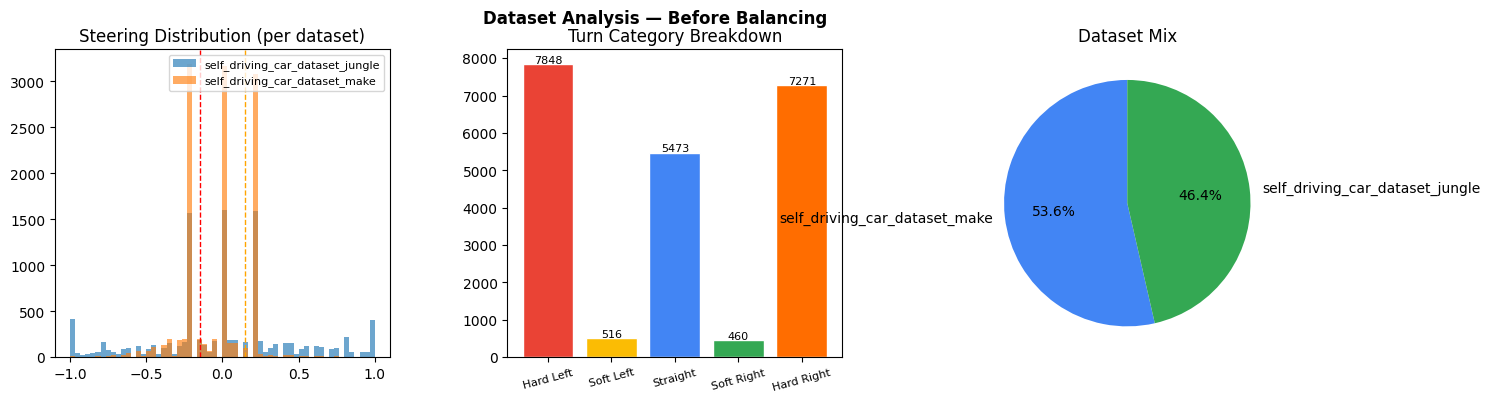

Hard-Right: 7271  |  Hard-Left: 8096  |  Straight: 5473
Imbalance : 0.8× more straight than hard-right


In [12]:
# Cell 5 — Visualise Distribution & Dataset Mix
fig = plt.figure(figsize=(16, 4))
gs  = fig.add_gridspec(1, 3, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
for name, grp in full_df.groupby('dataset'):
    ax1.hist(grp['steering'], bins=60, alpha=0.65, label=name, edgecolor='none')
ax1.axvline(CFG['LEFT_THRESH'],  color='red',    linestyle='--', linewidth=1)
ax1.axvline(CFG['RIGHT_THRESH'], color='orange', linestyle='--', linewidth=1)
ax1.set_title('Steering Distribution (per dataset)'); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[1])
bins_   = [-1, CFG['LEFT_THRESH'], CFG['STRAIGHT_LO'],
            CFG['STRAIGHT_HI'], CFG['RIGHT_THRESH'], 1]
labels_ = ['Hard Left','Soft Left','Straight','Soft Right','Hard Right']
colors_ = ['#EA4335','#FBBC04','#4285F4','#34A853','#FF6D00']
counts_ = pd.cut(full_df['steering'], bins=bins_, labels=labels_).value_counts()[labels_]
bars = ax2.bar(labels_, counts_.values, color=colors_, edgecolor='white')
for b, c in zip(bars, counts_.values):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+30, str(c), ha='center', fontsize=8)
ax2.set_title('Turn Category Breakdown'); ax2.set_xticklabels(labels_, rotation=15, fontsize=8)

ax3 = fig.add_subplot(gs[2])
src = full_df['dataset'].value_counts()
ax3.pie(src.values, labels=src.index, autopct='%1.1f%%',
        colors=['#4285F4','#34A853'], startangle=90)
ax3.set_title('Dataset Mix')

plt.suptitle('Dataset Analysis — Before Balancing', fontweight='bold')
plt.savefig('dataset_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

hard_r   = (full_df['steering'] > CFG['RIGHT_THRESH']).sum()
hard_l   = (full_df['steering'] < CFG['LEFT_THRESH']).sum()
straight = ((full_df['steering'] >= CFG['STRAIGHT_LO']) &
            (full_df['steering'] <= CFG['STRAIGHT_HI'])).sum()
print(f"Hard-Right: {hard_r}  |  Hard-Left: {hard_l}  |  Straight: {straight}")
print(f"Imbalance : {straight/max(hard_r,1):.1f}× more straight than hard-right")

✅ Preprocessing & augmentation defined


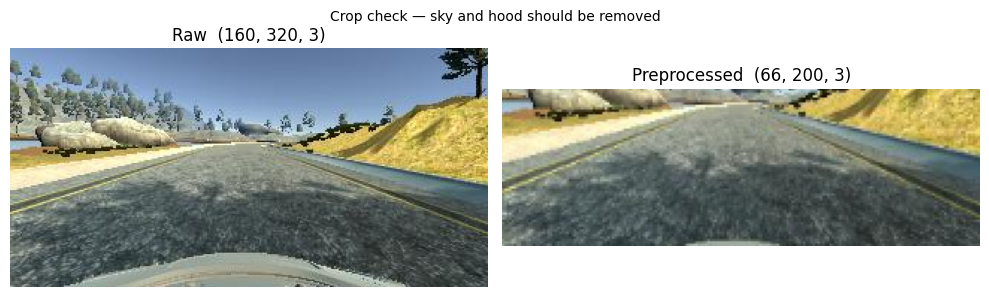

✅  Adjust CROP_TOP / CROP_BOT in CFG if sky or hood is still visible


In [13]:
# Cell 6 — Preprocessing & Augmentation
def preprocess(img_rgb):
    """Crop sky/hood, resize to 200×66, normalise to [-1, 1]."""
    h   = img_rgb.shape[0]
    img = img_rgb[CFG['CROP_TOP'] : h - CFG['CROP_BOT'], :]
    img = cv2.resize(img, (CFG['IMG_W'], CFG['IMG_H']))
    return img.astype(np.float32) / 127.5 - 1.0


def augment(img_rgb, angle, throttle, brake):
    """Augmentation: flip, brightness, shadow, translation, noise, zoom."""
    if np.random.rand() < 0.5:
        img_rgb = cv2.flip(img_rgb, 1);  angle = -angle

    if np.random.rand() < 0.65:
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:,:,2] *= 0.35 + np.random.rand() * 1.3
        hsv[:,:,2]  = np.clip(hsv[:,:,2], 0, 255)
        img_rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    if np.random.rand() < 0.55:
        h, w  = img_rgb.shape[:2]
        x1, x2 = np.random.randint(0, w, 2)
        pts = np.array([[x1,0],[x2,h],[0,h],[0,0]], dtype=np.int32)
        mask = np.zeros((h,w), dtype=np.float32)
        cv2.fillPoly(mask, [pts], 1)
        img_rgb = (img_rgb * (1 - 0.45*mask[:,:,None])).astype(np.uint8)

    if np.random.rand() < 0.5:
        tx = np.random.randint(-45, 45)
        M  = np.float32([[1,0,tx],[0,1,0]])
        img_rgb = cv2.warpAffine(img_rgb, M, (img_rgb.shape[1], img_rgb.shape[0]))
        angle   = np.clip(angle + tx * 0.0025, -1.0, 1.0)

    if np.random.rand() < 0.3:
        noise   = np.random.normal(0, 6, img_rgb.shape).astype(np.int16)
        img_rgb = np.clip(img_rgb.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    if np.random.rand() < 0.4:
        scale = 0.85 + np.random.rand()*0.3
        h, w  = img_rgb.shape[:2]
        nh, nw = int(h*scale), int(w*scale)
        img_rgb = cv2.resize(img_rgb, (nw, nh))
        dh = max(0,(nh-h)//2);  dw = max(0,(nw-w)//2)
        img_rgb = img_rgb[dh:dh+h, dw:dw+w]
        img_rgb = cv2.resize(img_rgb, (w, h))

    return img_rgb, float(angle), float(throttle), float(brake)

print("✅ Preprocessing & augmentation defined")

# Quick visual check
_row = full_df.iloc[0]
_bgr = cv2.imread(_row['img_path'])
if _bgr is not None:
    _rgb  = cv2.cvtColor(_bgr, cv2.COLOR_BGR2RGB)
    _proc = preprocess(_rgb)
    _disp = ((_proc + 1)*127.5).astype(np.uint8)
    fig, axes = plt.subplots(1, 2, figsize=(10,3))
    axes[0].imshow(_rgb);  axes[0].set_title(f'Raw  {_rgb.shape}');  axes[0].axis('off')
    axes[1].imshow(_disp); axes[1].set_title(f'Preprocessed  {_disp.shape}'); axes[1].axis('off')
    plt.suptitle('Crop check — sky and hood should be removed', fontsize=10)
    plt.tight_layout(); plt.savefig('preprocess_check.png', dpi=100); plt.show()
    print("✅  Adjust CROP_TOP / CROP_BOT in CFG if sky or hood is still visible")
else:
    print(f"⚠️  Could not read: {_row['img_path']}")

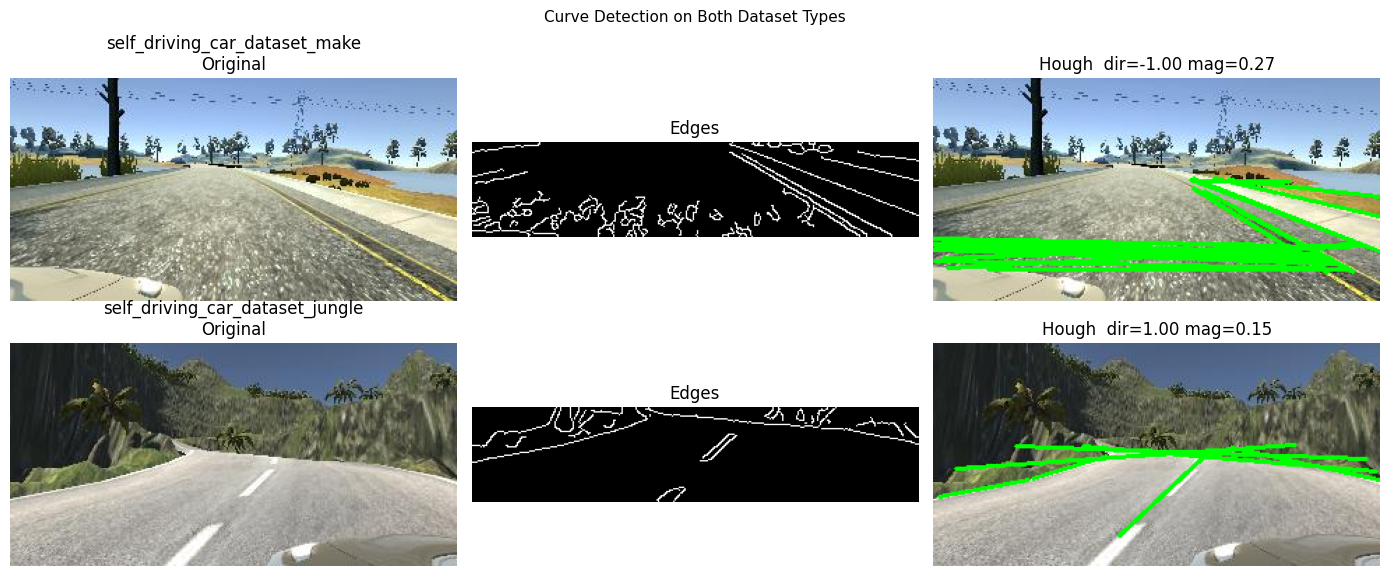

✅ Curve detection working


In [14]:
# Cell 7 — Curve Detection (Hough Lines)
def extract_curve_features(img_bgr):
    """6-dim curvature vector: [left_slope, right_slope, dir, mag, l_conf, r_conf]."""
    h, w  = img_bgr.shape[:2]
    roi   = img_bgr[int(h*0.45):int(h*0.88), :]
    gray  = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    blur  = cv2.GaussianBlur(gray, (7,7), 0)
    edges = cv2.Canny(blur, 40, 120)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, 35, minLineLength=25, maxLineGap=120)
    left_slopes, right_slopes = [], []
    if lines is not None:
        mid_x = w / 2
        for ln in lines:
            x1,y1,x2,y2 = ln[0]
            if x2==x1: continue
            slope = (y2-y1)/(x2-x1)
            if abs(slope) < 0.25: continue
            if   x1 < mid_x and x2 < mid_x:   left_slopes.append(slope)
            elif x1 > mid_x and x2 > mid_x: right_slopes.append(slope)
    ls = float(np.median(left_slopes))  if left_slopes  else 0.0
    rs = float(np.median(right_slopes)) if right_slopes else 0.0
    lc = min(len(left_slopes)/10.0,  1.0)
    rc = min(len(right_slopes)/10.0, 1.0)
    curve_dir = float(np.sign(ls+rs)*-1) if (ls!=0 or rs!=0) else 0.0
    curve_mag = min(abs(ls-rs)/2.0, 1.0)
    return np.array([np.clip(ls,-3,3)/3.0, np.clip(rs,-3,3)/3.0,
                     curve_dir, curve_mag, lc, rc], dtype=np.float32)

# Visualise on both dataset types
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Curve Detection on Both Dataset Types', fontsize=11)
for row_idx, ds_name in enumerate(full_df['dataset'].unique()[:2]):
    sample = full_df[full_df['dataset']==ds_name].iloc[5]
    bgr    = cv2.imread(sample['img_path'])
    if bgr is None: continue
    rgb    = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    feat   = extract_curve_features(bgr)
    h, w   = bgr.shape[:2]
    roi    = bgr[int(h*0.45):int(h*0.88), :]
    gray   = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    edges  = cv2.Canny(cv2.GaussianBlur(gray,(7,7),0), 40, 120)
    line_img = bgr.copy()
    lines    = cv2.HoughLinesP(edges,1,np.pi/180,35,minLineLength=25,maxLineGap=120)
    if lines is not None:
        for ln in lines:
            x1,y1,x2,y2 = ln[0]
            y1+=int(h*0.45); y2+=int(h*0.45)
            cv2.line(line_img,(x1,y1),(x2,y2),(0,255,0),2)
    axes[row_idx,0].imshow(rgb);                axes[row_idx,0].set_title(f'{ds_name}\nOriginal'); axes[row_idx,0].axis('off')
    axes[row_idx,1].imshow(edges,cmap='gray');  axes[row_idx,1].set_title('Edges'); axes[row_idx,1].axis('off')
    axes[row_idx,2].imshow(cv2.cvtColor(line_img,cv2.COLOR_BGR2RGB))
    axes[row_idx,2].set_title(f'Hough  dir={feat[2]:.2f} mag={feat[3]:.2f}'); axes[row_idx,2].axis('off')
plt.tight_layout(); plt.savefig('curve_detection.png',dpi=110); plt.show()
print("✅ Curve detection working")

In [15]:
# Cell 8 — Conditional DCGAN
class GANConfig:
    NZ, NC, NGF, NDF = CFG['GAN_LATENT'], 3, 64, 64
    N_CLS = 2;  SZ = CFG['GAN_IMG_SIZE']

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        nz,ngf,nc = GANConfig.NZ, GANConfig.NGF, GANConfig.NC
        self.embed = nn.Embedding(GANConfig.N_CLS, 50)
        self.proj  = nn.Sequential(nn.Linear(nz+50, ngf*8*4*4, bias=False),
                                   nn.Unflatten(1,(ngf*8,4,4)),
                                   nn.BatchNorm2d(ngf*8), nn.ReLU(True))
        self.up = nn.Sequential(
            nn.ConvTranspose2d(ngf*8,ngf*4,4,2,1,bias=False),nn.BatchNorm2d(ngf*4),nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4,ngf*2,4,2,1,bias=False),nn.BatchNorm2d(ngf*2),nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2,ngf,  4,2,1,bias=False),nn.BatchNorm2d(ngf),  nn.ReLU(True),
            nn.ConvTranspose2d(ngf,  nc,   4,2,1,bias=False),nn.Tanh())
    def forward(self,z,cls): return self.up(self.proj(torch.cat([z,self.embed(cls)],1)))

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        nc,ndf,sz = GANConfig.NC, GANConfig.NDF, GANConfig.SZ
        self.embed = nn.Embedding(GANConfig.N_CLS, sz*sz)
        self.main  = nn.Sequential(
            nn.Conv2d(nc+1,ndf,  4,2,1,bias=False),nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf,ndf*2, 4,2,1,bias=False),nn.BatchNorm2d(ndf*2),nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*2,ndf*4,4,2,1,bias=False),nn.BatchNorm2d(ndf*4),nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*4,ndf*8,4,2,1,bias=False),nn.BatchNorm2d(ndf*8),nn.LeakyReLU(0.2,True),
            nn.Conv2d(ndf*8,1,   4,1,0,bias=False),nn.Sigmoid())
    def forward(self,img,cls):
        e = self.embed(cls).view(-1,1,GANConfig.SZ,GANConfig.SZ)
        return self.main(torch.cat([img,e],1)).view(-1)

def weights_init(m):
    cn = m.__class__.__name__
    if 'Conv' in cn: nn.init.normal_(m.weight,0.0,0.02)
    elif 'BatchNorm' in cn: nn.init.normal_(m.weight,1.0,0.02); nn.init.constant_(m.bias,0)

print("✅ DCGAN defined")

✅ DCGAN defined


In [18]:
# Cell 9 — GAN Dataset (soft-turn images — YOUR real gap)
class TurnDataset(Dataset):
    def __init__(self, df, label):
        self.df=df.reset_index(drop=True); self.label=label; self.sz=GANConfig.SZ
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['img_path'])
        if img is None: img = np.random.randint(0,255,(160,320,3),dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(self.sz,self.sz)).astype(np.float32)
        img = (img/127.5)-1.0
        return torch.tensor(img).permute(2,0,1), torch.tensor(self.label,dtype=torch.long)

# ── Changed: now targets SOFT turns (your real gap) ──────────────
soft_left_data  = full_df[(full_df['steering'] >= CFG['LEFT_THRESH']) &
                           (full_df['steering'] <  CFG['STRAIGHT_LO'])].copy()
soft_right_data = full_df[(full_df['steering'] >  CFG['STRAIGHT_HI']) &
                           (full_df['steering'] <= CFG['RIGHT_THRESH'])].copy()

hard_left_data  = full_df[full_df['steering'] < CFG['LEFT_THRESH']].copy()
hard_right_data = full_df[full_df['steering'] > CFG['RIGHT_THRESH']].copy()

print(f"Soft-left  images (gap to fill): {len(soft_left_data):,}")
print(f"Soft-right images (gap to fill): {len(soft_right_data):,}")
print(f"Hard-left  images (reference)  : {len(hard_left_data):,}")
print(f"Hard-right images (reference)  : {len(hard_right_data):,}")
print(f"\nTarget: generate ~{len(hard_right_data) - len(soft_right_data):,} soft-right images")
print(f"Target: generate ~{len(hard_left_data)  - len(soft_left_data):,}  soft-left  images")

Soft-left  images (gap to fill): 702
Soft-right images (gap to fill): 460
Hard-left  images (reference)  : 8,096
Hard-right images (reference)  : 7,271

Target: generate ~6,811 soft-right images
Target: generate ~7,394  soft-left  images


Training DCGAN — 150 epochs on 1,162 turn images
(Set GAN_EPOCHS=30 in CFG for quick test)

  Epoch  10/150  G=3.4850  D=0.9078
  Epoch  20/150  G=2.5006  D=1.0715
  Epoch  30/150  G=2.8490  D=1.0034
  Epoch  40/150  G=2.7758  D=0.8946
  Epoch  50/150  G=2.8708  D=0.8269
  Epoch  60/150  G=2.5139  D=0.8258
  Epoch  70/150  G=2.5998  D=0.8068
  Epoch  80/150  G=2.5842  D=0.7434
  Epoch  90/150  G=2.6579  D=0.7602
  Epoch 100/150  G=2.7299  D=0.8160
  Epoch 110/150  G=2.5778  D=0.7700
  Epoch 120/150  G=2.6042  D=0.7497
  Epoch 130/150  G=2.6787  D=0.7530
  Epoch 140/150  G=2.6227  D=0.7411
  Epoch 150/150  G=2.5932  D=0.7193


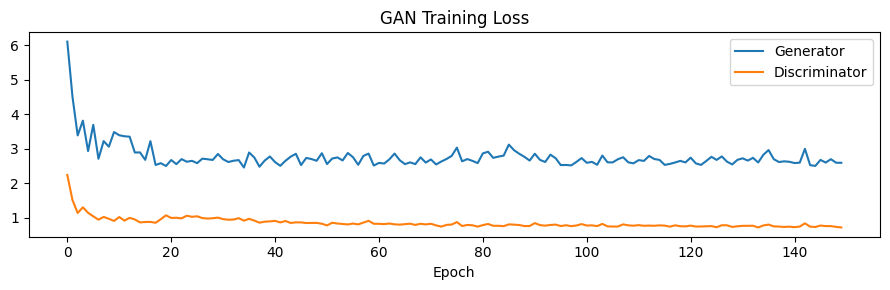


✅ GAN training complete


In [19]:
# Cell 10 — Train Conditional DCGAN
def train_gan(left_df, right_df):
    combined = torch.utils.data.ConcatDataset([TurnDataset(left_df,0), TurnDataset(right_df,1)])
    loader   = DataLoader(combined, batch_size=CFG['GAN_BATCH'], shuffle=True, num_workers=0, drop_last=True)
    G = Generator().to(DEVICE);  D = Discriminator().to(DEVICE)
    G.apply(weights_init);        D.apply(weights_init)
    opt_G = torch.optim.Adam(G.parameters(), lr=CFG['GAN_LR'], betas=(0.5,0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=CFG['GAN_LR'], betas=(0.5,0.999))
    bce   = nn.BCELoss()
    G_losses, D_losses = [], []
    epochs = CFG['GAN_EPOCHS']
    print(f"Training DCGAN — {epochs} epochs on {len(combined):,} turn images")
    print("(Set GAN_EPOCHS=30 in CFG for quick test)\n")
    for epoch in range(1, epochs+1):
        g_ep, d_ep = [], []
        for real_imgs, cls in loader:
            bs = real_imgs.size(0)
            real_imgs, cls = real_imgs.to(DEVICE), cls.to(DEVICE)
            D.zero_grad()
            r_out = D(real_imgs,cls)
            d_real= bce(r_out,torch.full((bs,),0.9,device=DEVICE))
            z     = torch.randn(bs,GANConfig.NZ,device=DEVICE)
            fake  = G(z,cls).detach()
            f_out = D(fake,cls)
            d_fake= bce(f_out,torch.full((bs,),0.1,device=DEVICE))
            (d_real+d_fake).backward(); opt_D.step()
            G.zero_grad()
            g_out = D(G(z,cls),cls)
            g_loss= bce(g_out,torch.ones(bs,device=DEVICE))
            g_loss.backward(); opt_G.step()
            g_ep.append(g_loss.item()); d_ep.append((d_real+d_fake).item())
        G_losses.append(np.mean(g_ep)); D_losses.append(np.mean(d_ep))
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  G={G_losses[-1]:.4f}  D={D_losses[-1]:.4f}")
    plt.figure(figsize=(9,3))
    plt.plot(G_losses,label='Generator'); plt.plot(D_losses,label='Discriminator')
    plt.title('GAN Training Loss'); plt.xlabel('Epoch'); plt.legend()
    plt.tight_layout(); plt.savefig('gan_loss.png',dpi=100); plt.show()
    return G

# ── ONLY THIS LINE CHANGED (soft turns instead of hard turns) ──
G_model = train_gan(soft_left_data, soft_right_data)
print("\n✅ GAN training complete")

Generating 6,811 synthetic SOFT-RIGHT images (angle 0.08→0.15)...
Generating 7,394  synthetic SOFT-LEFT  images (angle -0.15→-0.08)...


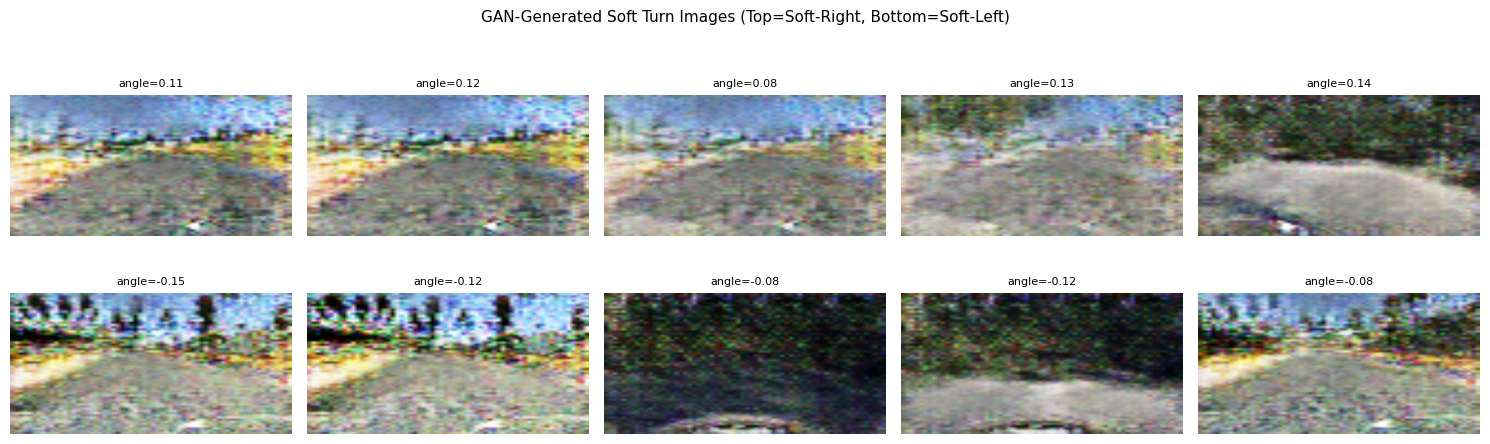

✅ 14,205 synthetic soft-turn images generated


In [20]:
# Cell 11 — Generate Synthetic SOFT Turn Images
SYNTH_DIR = '/content/synthetic_turns'
os.makedirs(SYNTH_DIR+'/soft_right', exist_ok=True)
os.makedirs(SYNTH_DIR+'/soft_left',  exist_ok=True)

def generate_synthetic(G, cls_id, n_images, folder, angle_range):
    G.eval(); records=[]; generated=0
    with torch.no_grad():
        while generated < n_images:
            bs  = min(64, n_images-generated)
            z   = torch.randn(bs,GANConfig.NZ,device=DEVICE)
            cls = torch.full((bs,),cls_id,dtype=torch.long,device=DEVICE)
            imgs = G(z,cls).cpu().numpy()
            for i,arr in enumerate(imgs):
                arr  = ((arr.transpose(1,2,0)+1)*127.5).clip(0,255).astype(np.uint8)
                bgr  = cv2.cvtColor(arr,cv2.COLOR_RGB2BGR)
                bgr  = cv2.resize(bgr,(320,160))
                path = f'{folder}/{generated+i:05d}.jpg'
                cv2.imwrite(path,bgr)
                angle = np.random.uniform(*angle_range)
                records.append({'img_path':path,'steering':angle,
                                'throttle':0.3,'brake':0.0,'speed':20.0,'dataset':'synthetic'})
            generated += bs
    G.train()
    return pd.DataFrame(records)

# ── Changed: soft angle ranges (0.08→0.15) instead of hard (0.20→0.90) ──
n_soft_right = len(hard_right_data) - len(soft_right_data)   # fill the gap
n_soft_left  = len(hard_left_data)  - len(soft_left_data)

print(f"Generating {n_soft_right:,} synthetic SOFT-RIGHT images (angle 0.08→0.15)...")
synth_right = generate_synthetic(G_model, 1, n_soft_right,
                                  SYNTH_DIR+'/soft_right', (0.08, 0.15))

print(f"Generating {n_soft_left:,}  synthetic SOFT-LEFT  images (angle -0.15→-0.08)...")
synth_left  = generate_synthetic(G_model, 0, n_soft_left,
                                  SYNTH_DIR+'/soft_left',  (-0.15, -0.08))

# Show samples
fig,axes=plt.subplots(2,5,figsize=(15,5))
fig.suptitle('GAN-Generated Soft Turn Images (Top=Soft-Right, Bottom=Soft-Left)',fontsize=11)
for col in range(5):
    for row,df_ in enumerate([synth_right,synth_left]):
        img = cv2.imread(df_.iloc[col*3]['img_path'])
        if img is not None: axes[row,col].imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
        axes[row,col].set_title(f"angle={df_.iloc[col*3]['steering']:.2f}",fontsize=8)
        axes[row,col].axis('off')
plt.tight_layout(); plt.savefig('synthetic_images.png',dpi=100); plt.show()
print(f"✅ {len(synth_right)+len(synth_left):,} synthetic soft-turn images generated")

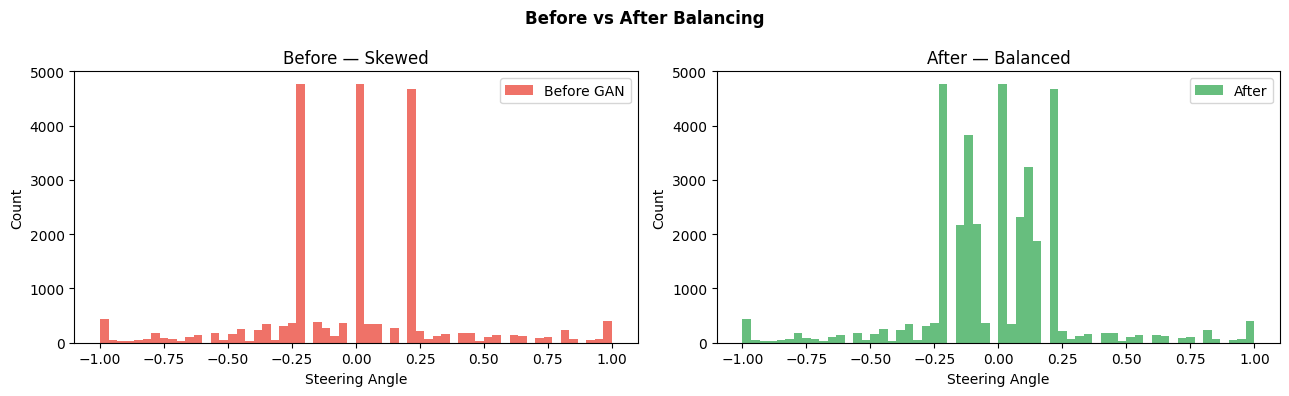

Total pool: 36,207  |  Sources: {'synthetic': 14205, 'self_driving_car_dataset_make': 11790, 'self_driving_car_dataset_jungle': 10212}


In [21]:
# Cell 12 — Combine Real + Synthetic, Show Final Distribution
combined_df = pd.concat([
    full_df[['img_path','steering','throttle','brake','speed','dataset']],
    synth_right, synth_left
], ignore_index=True).sample(frac=1,random_state=CFG['SEED']).reset_index(drop=True)

fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].hist(full_df['steering'],    bins=60,color='#EA4335',alpha=0.75,label='Before GAN')
axes[0].set_title('Before — Skewed')
axes[1].hist(combined_df['steering'],bins=60,color='#34A853',alpha=0.75,label='After')
axes[1].set_title('After — Balanced')
for ax in axes: ax.legend(); ax.set_xlabel('Steering Angle'); ax.set_ylabel('Count')
plt.suptitle('Before vs After Balancing',fontweight='bold')
plt.tight_layout(); plt.savefig('after_balancing.png',dpi=120); plt.show()
print(f"Total pool: {len(combined_df):,}  |  Sources: {combined_df['dataset'].value_counts().to_dict()}")

In [22]:
# Cell 13 — DrivingDataset
class DrivingDataset(Dataset):
    def __init__(self, df, training=True):
        self.df=df.reset_index(drop=True); self.training=training
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        bgr     = cv2.imread(row['img_path'])
        if bgr is None: bgr = np.zeros((160,320,3),dtype=np.uint8)
        curve_feat = extract_curve_features(bgr)
        rgb    = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        angle  = float(row['steering'])
        thr    = float(row.get('throttle',0.3))
        brk    = float(row.get('brake',0.0))
        if self.training:
            rgb,angle,thr,brk = augment(rgb,angle,thr,brk)
            curve_feat = extract_curve_features(cv2.cvtColor(rgb,cv2.COLOR_RGB2BGR))
        img = preprocess(rgb)
        img = torch.tensor(img.transpose(2,0,1),dtype=torch.float32)
        return (img,
                torch.tensor(curve_feat,dtype=torch.float32),
                torch.tensor(angle,dtype=torch.float32),
                torch.tensor(thr,  dtype=torch.float32),
                torch.tensor(brk,  dtype=torch.float32))
print("✅ DrivingDataset defined")

✅ DrivingDataset defined


In [23]:
# Cell 14 — WeightedRandomSampler + DataLoaders
train_df, val_df = train_test_split(combined_df, test_size=0.15, random_state=CFG['SEED'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

N_BINS     = 35
bin_edges  = np.linspace(-1.0,1.0,N_BINS+1)
bin_ids    = np.clip(np.digitize(train_df['steering'].values,bin_edges)-1, 0, N_BINS-1)
bin_counts = np.where(np.bincount(bin_ids,minlength=N_BINS)==0, 1,
                      np.bincount(bin_ids,minlength=N_BINS)).astype(float)
weights    = torch.tensor(1.0/bin_counts[bin_ids],dtype=torch.float64)
sampler    = WeightedRandomSampler(weights,num_samples=len(train_df),replacement=True)

train_ds     = DrivingDataset(train_df,training=True)
val_ds       = DrivingDataset(val_df,  training=False)
train_loader = DataLoader(train_ds,batch_size=CFG['BATCH'],sampler=sampler, num_workers=2,pin_memory=True)
val_loader   = DataLoader(val_ds,  batch_size=CFG['BATCH'],shuffle=False,   num_workers=2,pin_memory=True)
print(f"✅ Train: {len(train_ds):,}  |  Val: {len(val_ds):,}")
print(f"   Batches/epoch: {len(train_loader)}")

✅ Train: 30,775  |  Val: 5,432
   Batches/epoch: 962


In [24]:
# Cell 15 — FastSteerNet Architecture
class DSConv(nn.Module):
    def __init__(self,in_ch,out_ch,stride=1,kernel=3):
        super().__init__()
        self.dw  = nn.Conv2d(in_ch,in_ch,kernel,stride=stride,padding=kernel//2,groups=in_ch,bias=False)
        self.pw  = nn.Conv2d(in_ch,out_ch,1,bias=False)
        self.bn  = nn.BatchNorm2d(out_ch); self.act = nn.ELU(inplace=True)
    def forward(self,x): return self.act(self.bn(self.pw(self.dw(x))))

class FastSteerNet(nn.Module):
    def __init__(self,curve_dim=CFG['CURVE_DIM']):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3,32,5,stride=2,padding=1,bias=False),nn.BatchNorm2d(32),nn.ELU(inplace=True),
            nn.Conv2d(32,32,3,padding=1,bias=False),nn.BatchNorm2d(32),nn.ELU(inplace=True))
        self.backbone = nn.Sequential(
            DSConv(32,64,stride=2),DSConv(64,96,stride=2),
            DSConv(96,128,stride=2),DSConv(128,128,stride=1),DSConv(128,256,stride=1))
        self.sdrop = nn.Dropout2d(0.10); self.gap = nn.AdaptiveAvgPool2d(1)
        fc_in = 256 + curve_dim
        self.fc = nn.Sequential(nn.Linear(fc_in,128),nn.ELU(inplace=True),nn.Dropout(0.3),
                                nn.Linear(128,64),nn.ELU(inplace=True),nn.Dropout(0.2))
        self.steer_head    = nn.Linear(64,1)
        self.throttle_head = nn.Linear(64,1)
        self.brake_head    = nn.Linear(64,1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Conv2d): nn.init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
            elif isinstance(m,nn.BatchNorm2d): nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)
            elif isinstance(m,nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias,0)

    def forward(self,img,curve):
        x = self.stem(img); x = self.backbone(x)
        x = self.sdrop(x); x = self.gap(x).flatten(1)
        x = torch.cat([x,curve],dim=1); x = self.fc(x)
        return (torch.tanh(self.steer_head(x)),
                torch.sigmoid(self.throttle_head(x)),
                torch.sigmoid(self.brake_head(x)))

model = FastSteerNet().to(DEVICE)
_i = torch.randn(1,3,CFG['IMG_H'],CFG['IMG_W']).to(DEVICE)
_c = torch.randn(1,CFG['CURVE_DIM']).to(DEVICE)
with torch.no_grad(): s,t,b = model(_i,_c)
n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{'='*48}"); print(f"  FastSteerNet")
print(f"  Params : {n_p:,}  (~{n_p*4/1024/1024:.2f} MB fp32)")
print(f"  Inputs : {CFG['IMG_H']}×{CFG['IMG_W']} RGB + {CFG['CURVE_DIM']}-dim curve")
print(f"  Outputs: steering(tanh) | throttle(σ) | brake(σ)")
print(f"{'='*48}")

  FastSteerNet
  Params : 128,867  (~0.49 MB fp32)
  Inputs : 66×200 RGB + 6-dim curve
  Outputs: steering(tanh) | throttle(σ) | brake(σ)


In [26]:
# Cell 16 — Training
def multi_task_loss(ps,pt,pb,ts,tt,tb):
    sl = F.mse_loss(ps.squeeze(),ts) + 0.5*F.l1_loss(ps.squeeze(),ts)
    tl = F.mse_loss(pt.squeeze(),tt); bl = F.mse_loss(pb.squeeze(),tb)
    return 2.0*sl + 0.4*tl + 0.4*bl, sl

optimizer = torch.optim.AdamW(model.parameters(),lr=CFG['LR'],weight_decay=CFG['WEIGHT_DECAY'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5,
                                                        patience=4,min_lr=1e-6)
scaler    = GradScaler()
history   = {'train_loss':[],'val_loss':[],'steer_mse':[],'lr':[]}
best_val  = float('inf'); patience_cnt=0; best_weights=None

print(f"Training FastSteerNet — {CFG['EPOCHS']} epochs  |  early stop patience={CFG['PATIENCE']}\n")
for epoch in range(1,CFG['EPOCHS']+1):
    model.train(); t_loss=0
    for imgs,curves,angles,throttles,brakes in tqdm(train_loader,desc=f'Ep {epoch:3d}',leave=False):
        imgs,curves = imgs.to(DEVICE),curves.to(DEVICE)
        angles,throttles,brakes = angles.to(DEVICE),throttles.to(DEVICE),brakes.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            ps,pt,pb = model(imgs,curves); loss,_ = multi_task_loss(ps,pt,pb,angles,throttles,brakes)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(),1.0)
        scaler.step(optimizer); scaler.update(); t_loss+=loss.item()
    model.eval(); v_loss=0; s_mse=0; all_pred=[]; all_true=[]
    with torch.no_grad():
        for imgs,curves,angles,throttles,brakes in val_loader:
            imgs,curves = imgs.to(DEVICE),curves.to(DEVICE)
            angles,throttles,brakes = angles.to(DEVICE),throttles.to(DEVICE),brakes.to(DEVICE)
            ps,pt,pb = model(imgs,curves); loss,sl = multi_task_loss(ps,pt,pb,angles,throttles,brakes)
            v_loss+=loss.item(); s_mse+=sl.item()
            all_pred.extend(ps.squeeze().cpu().numpy()); all_true.extend(angles.cpu().numpy())
    ta=t_loss/len(train_loader); va=v_loss/len(val_loader)
    sa=s_mse/len(val_loader);    lr=optimizer.param_groups[0]['lr']
    history['train_loss'].append(ta); history['val_loss'].append(va)
    history['steer_mse'].append(sa);  history['lr'].append(lr)
    scheduler.step(va)
    print(f"Ep {epoch:3d} | Train {ta:.5f} | Val {va:.5f} | SteerMSE {sa:.5f} | LR {lr:.6f}")
    if va < best_val:
        best_val=va; patience_cnt=0; best_weights=copy.deepcopy(model.state_dict())
        torch.save({'epoch':epoch,'model_state_dict':best_weights,'val_loss':best_val,'cfg':CFG},'best_model.pth')
        print(f"           ✅ Best saved (val={best_val:.5f})")
    else:
        patience_cnt+=1
        if patience_cnt >= CFG['PATIENCE']: print(f"\n⚠️  Early stopping at epoch {epoch}"); break
model.load_state_dict(best_weights)
print(f"\n✅ Done. Best val loss: {best_val:.5f}")

Training FastSteerNet — 60 epochs  |  early stop patience=10



Ep   1 | Train 0.65194 | Val 0.29223 | SteerMSE 0.13951 | LR 0.001000
           ✅ Best saved (val=0.29223)


Ep   2 | Train 0.43491 | Val 0.36787 | SteerMSE 0.18223 | LR 0.001000


Ep   3 | Train 0.37423 | Val 0.26402 | SteerMSE 0.13125 | LR 0.001000
           ✅ Best saved (val=0.26402)


Ep   4 | Train 0.34800 | Val 0.25843 | SteerMSE 0.12788 | LR 0.001000
           ✅ Best saved (val=0.25843)


...

Ep  56 | Train 0.13053 | Val 0.16744 | SteerMSE 0.08335 | LR 0.000125


Ep  57 | Train 0.13169 | Val 0.15914 | SteerMSE 0.07930 | LR 0.000063


Ep  58 | Train 0.12981 | Val 0.16166 | SteerMSE 0.08057 | LR 0.000063


Ep  59 | Train 0.12972 | Val 0.16121 | SteerMSE 0.08031 | LR 0.000063


Ep  60 | Train 0.12912 | Val 0.15857 | SteerMSE 0.07905 | LR 0.000063

✅ Done. Best val loss: 0.15795


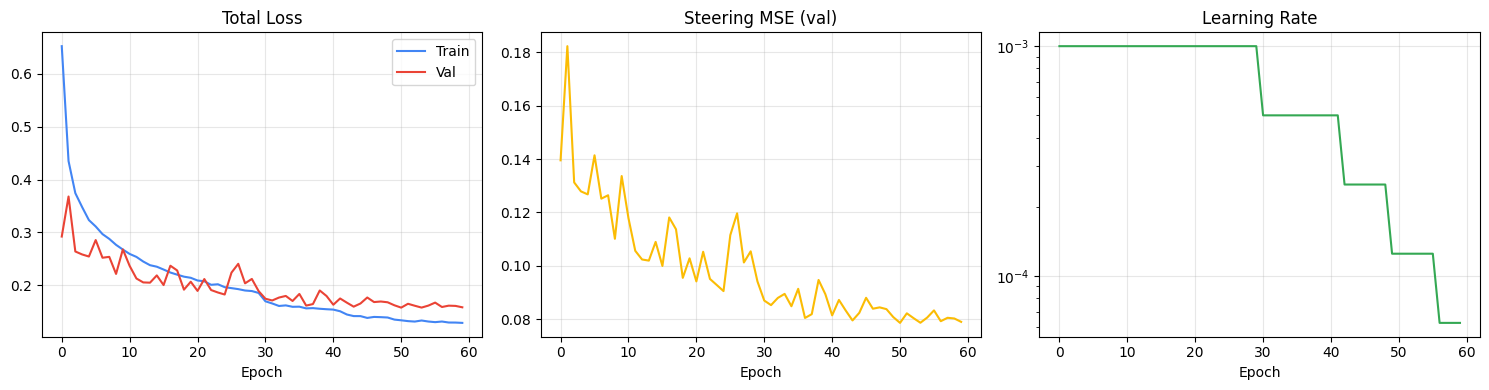

In [27]:
# Cell 17 — Training Curves
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].plot(history['train_loss'],label='Train',color='#4285F4')
axes[0].plot(history['val_loss'],  label='Val',  color='#EA4335')
axes[0].set_title('Total Loss'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(history['steer_mse'],color='#FBBC04')
axes[1].set_title('Steering MSE (val)'); axes[1].grid(True,alpha=0.3)
axes[2].plot(history['lr'],color='#34A853')
axes[2].set_title('Learning Rate'); axes[2].set_yscale('log'); axes[2].grid(True,alpha=0.3)
for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout(); plt.savefig('training_curves.png',dpi=120,bbox_inches='tight'); plt.show()

  MSE  : 0.027983
  RMSE : 0.167282
  MAE  : 0.101383
  R²   : 0.6376  (63.8%)


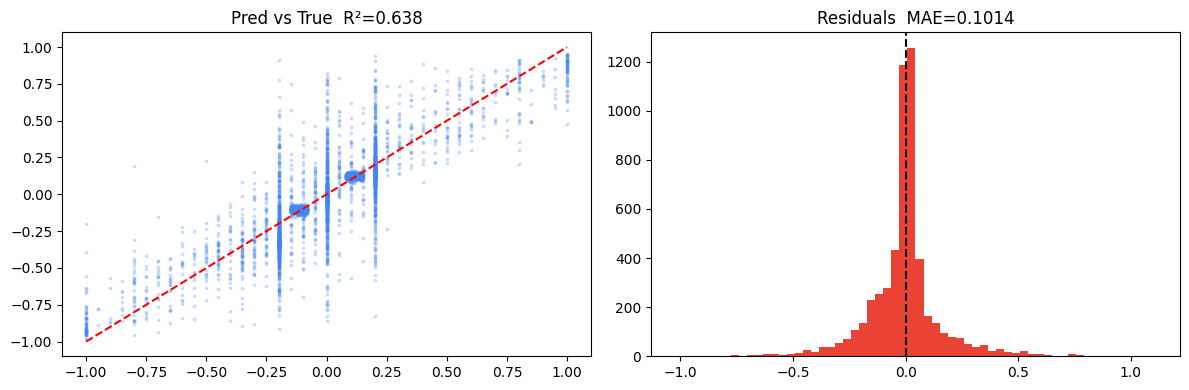

In [28]:
# Cell 18 — Evaluation Metrics
model.eval(); all_pred=[]; all_true=[]
with torch.no_grad():
    for imgs,curves,angles,_,_ in val_loader:
        ps,_,_ = model(imgs.to(DEVICE),curves.to(DEVICE))
        all_pred.extend(ps.squeeze().cpu().numpy()); all_true.extend(angles.numpy())
preds=np.array(all_pred); truth=np.array(all_true)
mse_=mean_squared_error(truth,preds); mae_=mean_absolute_error(truth,preds)
r2_ =r2_score(truth,preds);          rmse_=np.sqrt(mse_)
print(f"{'='*48}")
print(f"  MSE  : {mse_:.6f}")
print(f"  RMSE : {rmse_:.6f}")
print(f"  MAE  : {mae_:.6f}")
print(f"  R²   : {r2_:.4f}  ({r2_*100:.1f}%)")
print(f"{'='*48}")
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].scatter(truth,preds,alpha=0.2,s=3,color='#4285F4')
axes[0].plot([-1,1],[-1,1],'r--'); axes[0].set_title(f'Pred vs True  R²={r2_:.3f}')
residuals=preds-truth
axes[1].hist(residuals,bins=60,color='#EA4335',edgecolor='none')
axes[1].axvline(0,color='black',linestyle='--'); axes[1].set_title(f'Residuals  MAE={mae_:.4f}')
plt.tight_layout(); plt.savefig('evaluation.png',dpi=120,bbox_inches='tight'); plt.show()

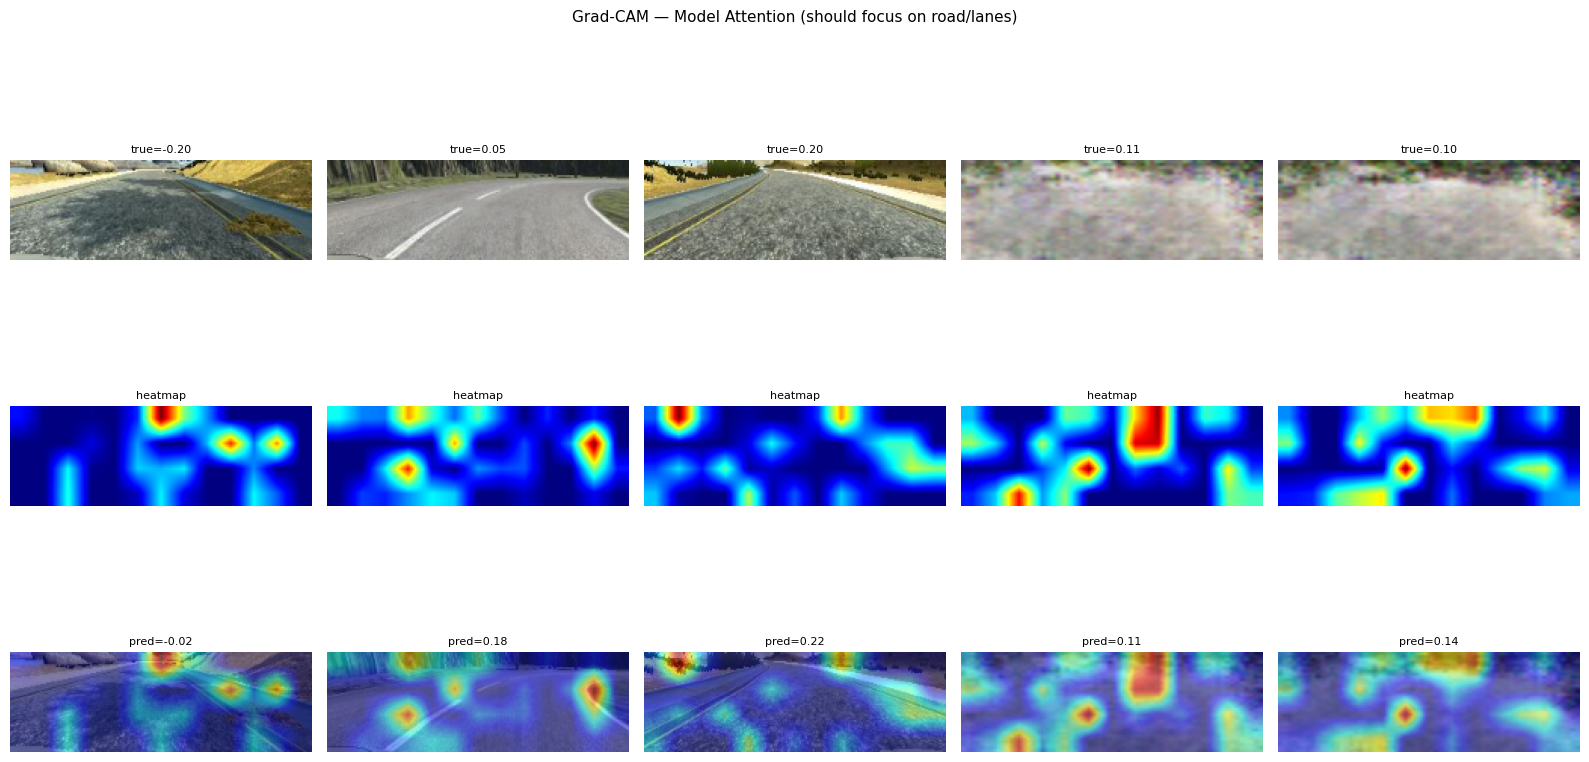

In [29]:
# Cell 19 — Grad-CAM
class GradCAM:
    def __init__(self,model,target_layer):
        self.gradients=None; self.activations=None
        target_layer.register_forward_hook( lambda m,i,o: setattr(self,'activations',o.detach()))
        target_layer.register_backward_hook(lambda m,gi,go: setattr(self,'gradients',go[0].detach()))
    def generate(self,img_t,curve_t):
        model.eval(); img_t=img_t.requires_grad_(True)
        s,_,_ = model(img_t,curve_t); model.zero_grad(); s.sum().backward()
        w   = self.gradients.mean(dim=(2,3),keepdim=True)
        cam = F.relu((w*self.activations).sum(dim=1,keepdim=True))
        cam = F.interpolate(cam,(CFG['IMG_H'],CFG['IMG_W']),mode='bilinear',align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8)

gcam = GradCAM(model, model.backbone[-1].bn)
fig,axes=plt.subplots(3,5,figsize=(16,9))
fig.suptitle('Grad-CAM — Model Attention (should focus on road/lanes)',fontsize=11)
idxs = np.random.choice(len(val_ds),5,replace=False)
for col,idx in enumerate(idxs):
    img_t,curve_t,angle,_,_ = val_ds[idx]
    cam  = gcam.generate(img_t.unsqueeze(0).to(DEVICE),curve_t.unsqueeze(0).to(DEVICE))
    disp = ((img_t.numpy().transpose(1,2,0)+1)*127.5).clip(0,255).astype(np.uint8)
    heat = cv2.cvtColor(cv2.applyColorMap((cam*255).astype(np.uint8),cv2.COLORMAP_JET),cv2.COLOR_BGR2RGB)
    ovrl = cv2.addWeighted(disp,0.5,heat,0.5,0)
    with torch.no_grad():
        ps,_,_ = model(img_t.unsqueeze(0).to(DEVICE),curve_t.unsqueeze(0).to(DEVICE))
    axes[0,col].imshow(disp);  axes[0,col].set_title(f'true={angle:.2f}',fontsize=8); axes[0,col].axis('off')
    axes[1,col].imshow(heat);  axes[1,col].set_title('heatmap',fontsize=8);            axes[1,col].axis('off')
    axes[2,col].imshow(ovrl);  axes[2,col].set_title(f'pred={ps.item():.2f}',fontsize=8);axes[2,col].axis('off')
plt.tight_layout(); plt.savefig('gradcam.png',dpi=110,bbox_inches='tight'); plt.show()

In [30]:
# Cell 20 — Pruning + INT8 Quantization
import torch.nn.utils.prune as prune
import torch.quantization as tq

model_pruned = copy.deepcopy(model)
for _,module in model_pruned.named_modules():
    if isinstance(module,nn.Linear):
        prune.l1_unstructured(module,'weight',amount=0.25); prune.remove(module,'weight')
total   = sum(p.numel() for p in model_pruned.parameters())
nonzero = sum(p.count_nonzero().item() for p in model_pruned.parameters())
print(f"Pruning: {nonzero:,}/{total:,} non-zero  ({nonzero/total*100:.1f}% remaining)")

model_q = tq.quantize_dynamic(copy.deepcopy(model).cpu(),{nn.Linear},dtype=torch.qint8)
model_q.eval()
with torch.no_grad():
    for i,(imgs,curves,*_) in enumerate(val_loader):
        _ = model_q(imgs,curves)
        if i>=5: break

import tempfile
def model_mb(m):
    p=tempfile.mktemp()+'.pth'; torch.save(m.state_dict(),p); s=os.path.getsize(p)/1024/1024; os.remove(p); return s
print(f"\nOriginal fp32 : {model_mb(model):.2f} MB")
print(f"INT8 quantized: {model_mb(model_q):.2f} MB")
model=model.to(DEVICE)

Pruning: 118,387/128,867 non-zero  (91.9% remaining)

Original fp32 : 0.52 MB
INT8 quantized: 0.40 MB


In [32]:
import torch.nn.utils.prune as prune
import torch.quantization as tq

model_pruned = copy.deepcopy(model)
for _,module in model_pruned.named_modules():
    if isinstance(module,nn.Linear):
        prune.l1_unstructured(module,'weight',amount=0.25); prune.remove(module,'weight')
total   = sum(p.numel() for p in model_pruned.parameters())
nonzero = sum(p.count_nonzero().item() for p in model_pruned.parameters())
print(f"Pruning: {nonzero:,}/{total:,} non-zero  ({nonzero/total*100:.1f}% remaining)")

model_q = tq.quantize_dynamic(copy.deepcopy(model).cpu(),{nn.Linear},dtype=torch.qint8)
model_q.eval()
with torch.no_grad():
    for i,(imgs,curves,*_) in enumerate(val_loader):
        _ = model_q(imgs,curves)
        if i>=5: break

import tempfile
def model_mb(m):
    p=tempfile.mktemp()+'.pth'; torch.save(m.state_dict(),p); s=os.path.getsize(p)/1024/1024; os.remove(p); return s
print(f"\nOriginal fp32 : {model_mb(model):.2f} MB")
print(f"INT8 quantized: {model_mb(model_q):.2f} MB")
model=model.to(DEVICE)


# --- FIX START ---
# Create a clean model instance for scripting and ONNX export
# This avoids issues with backward hooks attached by GradCAM
model_for_export = FastSteerNet().to(DEVICE)
model_for_export.load_state_dict(best_weights)
model_for_export.eval()
# --- FIX END ---


os.makedirs('/content/saved_models',exist_ok=True)
torch.save({'epoch':CFG['EPOCHS'],'model_state_dict':model.state_dict(),
            'val_loss':best_val,'r2':r2_,'mae':mae_,'cfg':CFG},
           '/content/saved_models/faststeernet_checkpoint.pth')
torch.save(model.state_dict(),'/content/saved_models/faststeernet_weights.pth')
torch.save(model_q.state_dict(),'/content/saved_models/faststeernet_int8.pth')
# model.eval() # Eval mode is already set for model_for_export
_di=torch.randn(1,3,CFG['IMG_H'],CFG['IMG_W']).to(DEVICE)
_dc=torch.randn(1,CFG['CURVE_DIM']).to(DEVICE)
scripted=torch.jit.trace(model_for_export,(_di,_dc))
scripted.save('/content/saved_models/faststeernet_torchscript.pt')
try:
    torch.onnx.export(model_for_export,(_di,_dc),'/content/saved_models/faststeernet.onnx',
                      input_names=['image','curve'],output_names=['steering','throttle','brake'],
                      dynamic_axes={'image':{0:'batch'},'curve':{0:'batch'}},opset_version=14,verbose=False)
    print("✅ ONNX exported")
except Exception as e: print(f"⚠️  ONNX: {e}")
print("\n── Saved files ──────────────────────────────")
for f in sorted(os.listdir('/content/saved_models')):
    sz=os.path.getsize(f'/content/saved_models/{f}')/1024/1024
    print(f"  {f:<45} {sz:.2f} MB")

Pruning: 118,387/128,867 non-zero  (91.9% remaining)

Original fp32 : 0.52 MB
INT8 quantized: 0.40 MB
⚠️  ONNX: No module named 'onnxscript'

── Saved files ──────────────────────────────
  faststeernet_checkpoint.pth                   0.52 MB
  faststeernet_int8.pth                         0.40 MB
  faststeernet_torchscript.pt                   0.59 MB
  faststeernet_weights.pth                      0.52 MB


In [33]:
# Cell 22 — Latency Benchmark
model.eval()
_di=torch.randn(1,3,CFG['IMG_H'],CFG['IMG_W']).to(DEVICE)
_dc=torch.randn(1,CFG['CURVE_DIM']).to(DEVICE)
with torch.no_grad():
    for _ in range(30): model(_di,_dc)
N=500; times=[]
if torch.cuda.is_available(): torch.cuda.synchronize()
with torch.no_grad():
    for _ in range(N):
        t0=time.perf_counter(); model(_di,_dc)
        if torch.cuda.is_available(): torch.cuda.synchronize()
        times.append((time.perf_counter()-t0)*1000)
times=np.array(times)
print(f"{'='*50}")
print(f"  Latency ({N} runs, batch=1)")
print(f"  Device : {DEVICE}")
print(f"  Mean   : {times.mean():.2f} ms  |  Std: {times.std():.2f} ms")
print(f"  P95    : {np.percentile(times,95):.2f} ms  |  P99: {np.percentile(times,99):.2f} ms")
print(f"  FPS    : {1000/times.mean():.0f}")
print(f"{'='*50}")

  Latency (500 runs, batch=1)
  Device : cuda
  Mean   : 2.18 ms  |  Std: 0.60 ms
  P95    : 3.83 ms  |  P99: 4.28 ms
  FPS    : 459


In [34]:
# Cell 23 — Final Summary
n_params = sum(p.numel() for p in model.parameters())
print("\n"+"="*55)
print("  FastSteerNet — COMPLETE")
print("="*55)
print(f"  Datasets   : {[os.path.basename(p) for p in CFG['DATA_PATHS']]}")
print(f"  Params     : {n_params:,}  (~{n_params*4/1024/1024:.2f} MB fp32)")
print(f"  R²         : {r2_:.4f}  ({r2_*100:.1f}%)")
print(f"  MAE        : {mae_:.5f}")
print(f"  RMSE       : {rmse_:.5f}")
print(f"  Latency    : {times.mean():.2f} ms mean  |  {np.percentile(times,99):.2f} ms P99")
print(f"  FPS        : {1000/times.mean():.0f}")
print(f"  Models     : /content/saved_models/  (5 formats)")
print("="*55)


  FastSteerNet — COMPLETE
  Datasets   : ['self_driving_car_dataset_jungle', 'self_driving_car_dataset_make']
  Params     : 128,867  (~0.49 MB fp32)
  R²         : 0.6376  (63.8%)
  MAE        : 0.10138
  RMSE       : 0.16728
  Latency    : 2.18 ms mean  |  4.28 ms P99
  FPS        : 459
  Models     : /content/saved_models/  (5 formats)
